In [2]:
!pip install librosa
!pip install tensorflow
!pip install matplotlib
!pip install numpy

In [4]:
import tensorflow as tf
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import os

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("neehakurelli/google-speech-commands")

print("Path to dataset files:", path)

100%|██████████| 1.38G/1.38G [00:48<00:00, 30.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/neehakurelli/google-speech-commands/versions/1


In [6]:
import os

print(os.listdir(path))

['dog', 'four', 'README.md', '_background_noise_', 'marvin', 'sheila', 'three', 'left', 'two', 'up', 'wow', 'nine', 'five', 'house', 'zero', 'tree', 'bird', 'bed', 'eight', 'seven', 'happy', 'one', 'testing_list.txt', 'right', 'yes', 'go', 'no', 'down', 'six', 'cat', 'validation_list.txt', 'LICENSE', 'off', 'on', 'stop']


In [7]:
import os

sample_folder = os.path.join(path, "yes")
files = os.listdir(sample_folder)

print(files[:5])

['ffd2ba2f_nohash_0.wav', 'b43de700_nohash_0.wav', 'a5b24175_nohash_2.wav', '39a12648_nohash_0.wav', '09bcdc9d_nohash_0.wav']


In [8]:
audio_file = os.path.join(sample_folder, files[0])

print(audio_file)

/root/.cache/kagglehub/datasets/neehakurelli/google-speech-commands/versions/1/yes/ffd2ba2f_nohash_0.wav


In [9]:
import librosa

signal, sr = librosa.load(audio_file)

print("Sampling Rate:", sr)
print("Signal Shape:", signal.shape)

Sampling Rate: 22050
Signal Shape: (22050,)


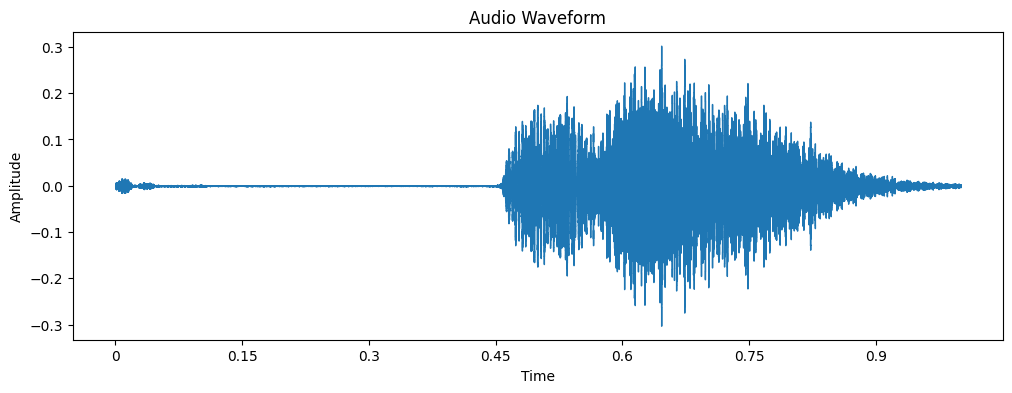

In [10]:
import librosa.display
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
librosa.display.waveshow(signal, sr=sr)

plt.title("Audio Waveform")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.show()

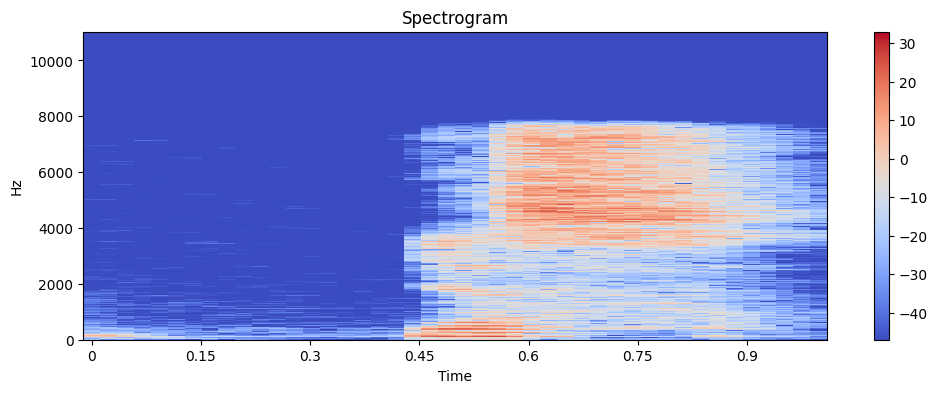

In [11]:
import numpy as np

spectrogram = librosa.stft(signal)

spectrogram_db = librosa.amplitude_to_db(abs(spectrogram))

plt.figure(figsize=(12,4))

librosa.display.specshow(
    spectrogram_db,
    sr=sr,
    x_axis="time",
    y_axis="hz"
)

plt.title("Spectrogram")
plt.colorbar()

plt.show()

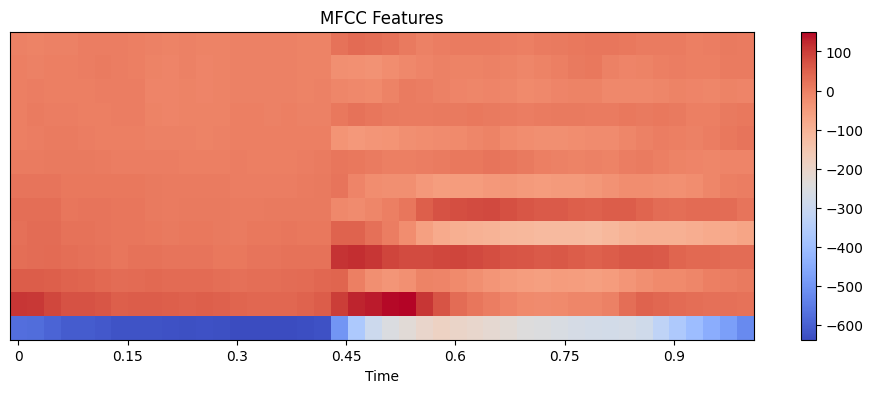

In [12]:
mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)

plt.figure(figsize=(12,4))

librosa.display.specshow(
    mfcc,
    x_axis="time"
)

plt.colorbar()

plt.title("MFCC Features")

plt.show()

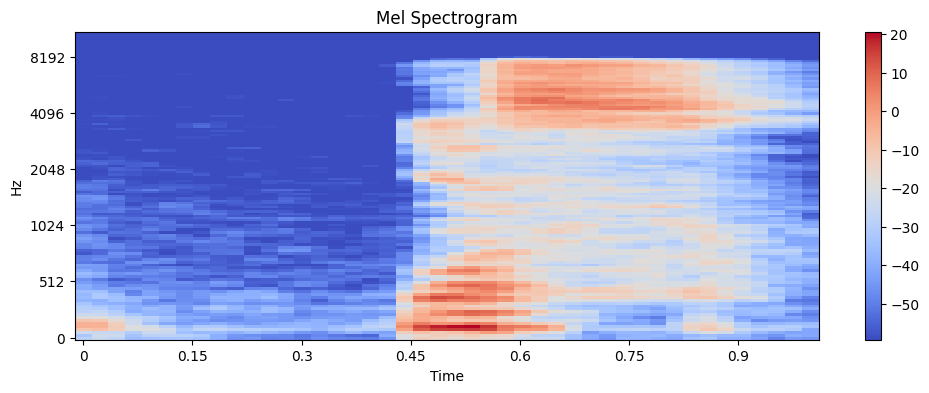

In [13]:
mel = librosa.feature.melspectrogram(y=signal, sr=sr)

mel_db = librosa.power_to_db(mel)

plt.figure(figsize=(12,4))

librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar()

plt.title("Mel Spectrogram")

plt.show()

In [14]:
noise = np.random.randn(len(signal))

signal_noise = signal + 0.005 * noise

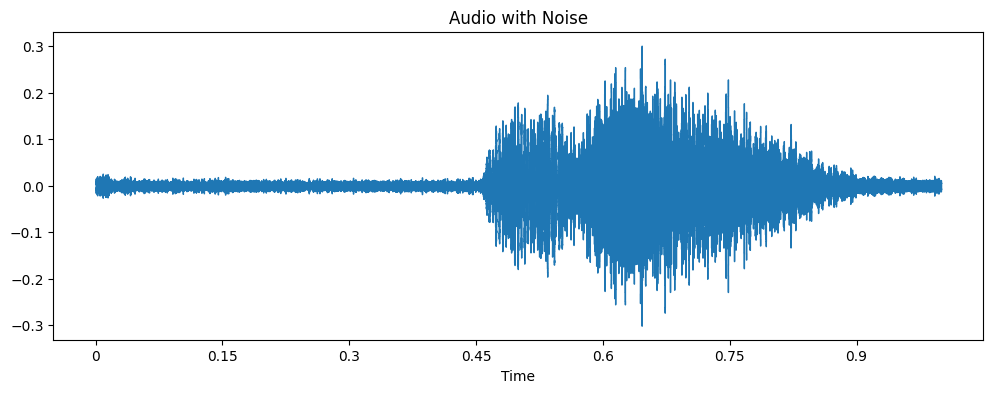

In [15]:
plt.figure(figsize=(12,4))

librosa.display.waveshow(signal_noise, sr=sr)

plt.title("Audio with Noise")

plt.show()

In [16]:
signal_pitch = librosa.effects.pitch_shift(signal, sr=sr, n_steps=3)

In [17]:
shift = int(sr * 0.1)

signal_shift = np.roll(signal, shift)

In [18]:
import tensorflow as tf

audio_tensor = tf.convert_to_tensor(signal)

print(audio_tensor)

tf.Tensor(
[-1.7093964e-03 -2.2005988e-03 -2.1899301e-03 ...  2.4155967e-03
  2.1551282e-03 -1.6621198e-05], shape=(22050,), dtype=float32)


In [19]:
np.save("mfcc_features.npy", mfcc)

In [20]:
features = []

for file in files[:50]:

    file_path = os.path.join(sample_folder, file)

    signal, sr = librosa.load(file_path)

    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)

    features.append(mfcc)

print("Processed files:", len(features))

Processed files: 50
